In [3]:
# ─── Step 1: Import Libraries ───────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

In [4]:
# ─── Step 2: Load and Explore the Data ──────────────────────────────────────

df = pd.read_csv('online_retail.csv', encoding='latin1')

# Basic shape and structure
print("Shape:", df.shape)
print()
print("Column Names:", df.columns.tolist())
print()
print("Data Types:\n", df.dtypes)
print()
print("First 5 rows:")
df.head()

Shape: (541909, 8)

Column Names: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types:
 InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2022 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2022 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2022 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2022 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2022 8:26,3.39,17850.0,United Kingdom


In [5]:
# ─── Step 2 continued: Missing Values & Duplicates ──────────────────────────

print("Missing Values:\n", df.isnull().sum())
print()
print("Duplicate Rows:", df.duplicated().sum())
print()
print("Basic Stats:")
df.describe()

Missing Values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate Rows: 5268

Basic Stats:


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [6]:
# ─── Step 3: Data Preprocessing ─────────────────────────────────────────────

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove duplicate rows
df = df.drop_duplicates()

# Remove cancelled invoices (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove rows with negative or zero Quantity and UnitPrice
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# Convert CustomerID to integer
df['CustomerID'] = df['CustomerID'].astype(int)

# Confirm clean dataset
print("Clean dataset shape:", df.shape)
print()
print("Missing values after cleaning:\n", df.isnull().sum())
print()
print("Date range:", df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())

Clean dataset shape: (392692, 8)

Missing values after cleaning:
 InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Date range: 2022-12-01 08:26:00 to 2023-12-09 12:50:00


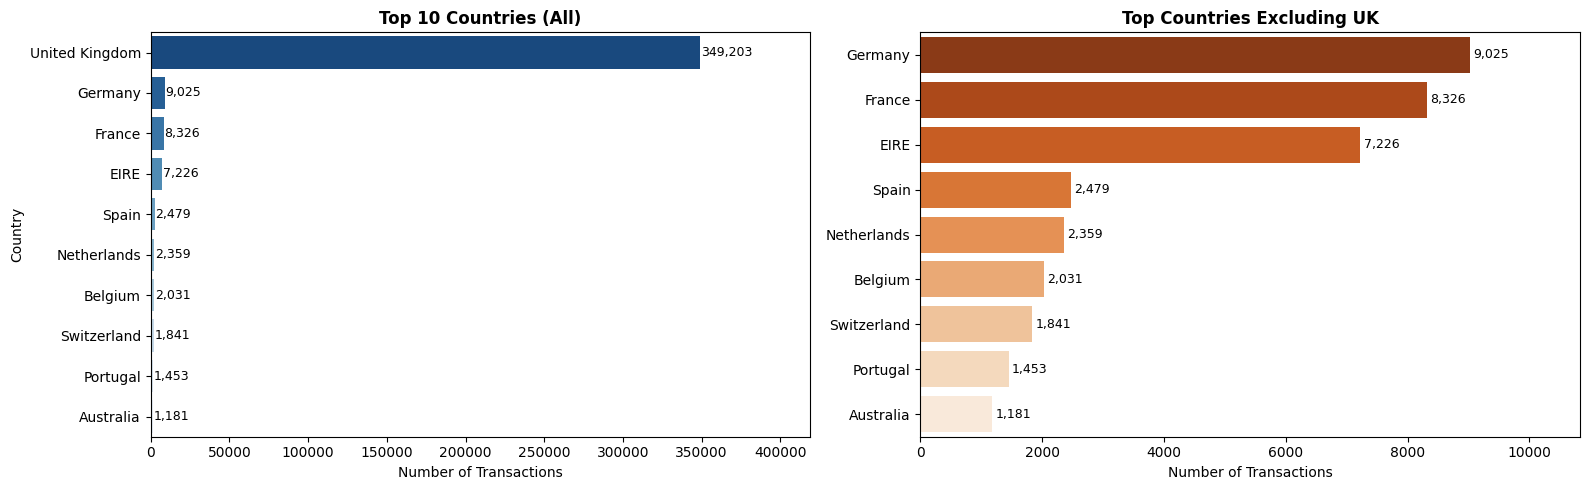

In [7]:
# ─── Step 4: EDA ─────────────────────────────────────────────────────────────

# Chart 1: Top 10 Countries by Transaction Volume (excluding UK for visibility)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: All top 10 with actual values
top_countries = df['Country'].value_counts().head(10)
ax1 = sns.barplot(x=top_countries.values, y=top_countries.index, palette='Blues_r', ax=axes[0])
for i, v in enumerate(top_countries.values):
    ax1.text(v + 500, i, f'{v:,}', va='center', fontsize=9)
axes[0].set_title('Top 10 Countries (All)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Transactions')
axes[0].set_ylabel('Country')
axes[0].set_xlim(0, top_countries.values.max() * 1.2)

# Right: Excluding UK to see other countries clearly
top_ex_uk = df[df['Country'] != 'United Kingdom']['Country'].value_counts().head(9)
ax2 = sns.barplot(x=top_ex_uk.values, y=top_ex_uk.index, palette='Oranges_r', ax=axes[1])
for i, v in enumerate(top_ex_uk.values):
    ax2.text(v + 50, i, f'{v:,}', va='center', fontsize=9)
axes[1].set_title('Top Countries Excluding UK', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Transactions')
axes[1].set_ylabel('')
axes[1].set_xlim(0, top_ex_uk.values.max() * 1.2)

plt.tight_layout()
plt.show()

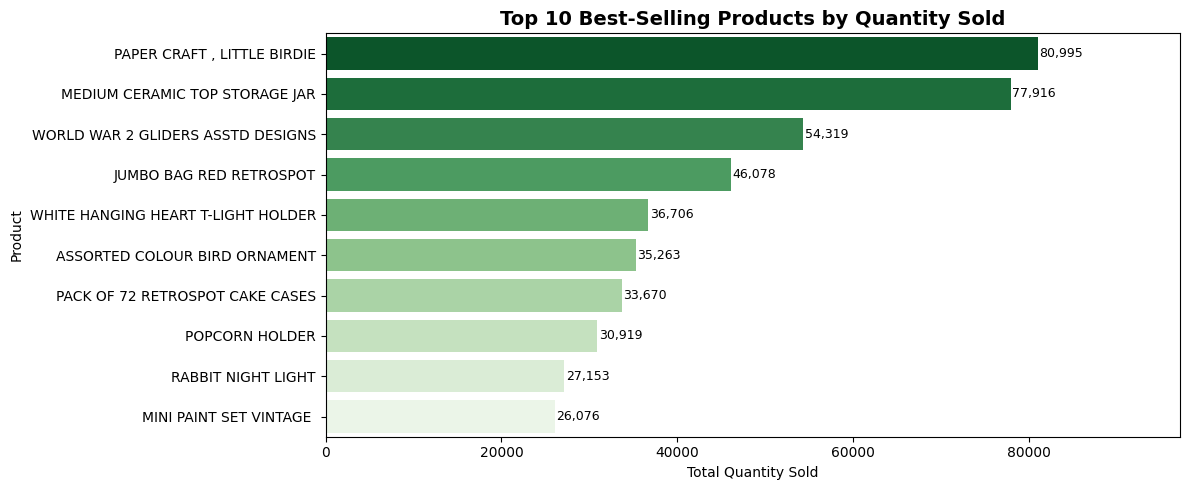

In [8]:
# Chart 2: Top 10 Best-Selling Products by Quantity Sold
plt.figure(figsize=(12, 5))
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
ax = sns.barplot(x=top_products.values, y=top_products.index, palette='Greens_r')
for i, v in enumerate(top_products.values):
    ax.text(v + 200, i, f'{v:,}', va='center', fontsize=9)
plt.title('Top 10 Best-Selling Products by Quantity Sold', fontsize=14, fontweight='bold')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.xlim(0, top_products.values.max() * 1.2)
plt.tight_layout()
plt.show()

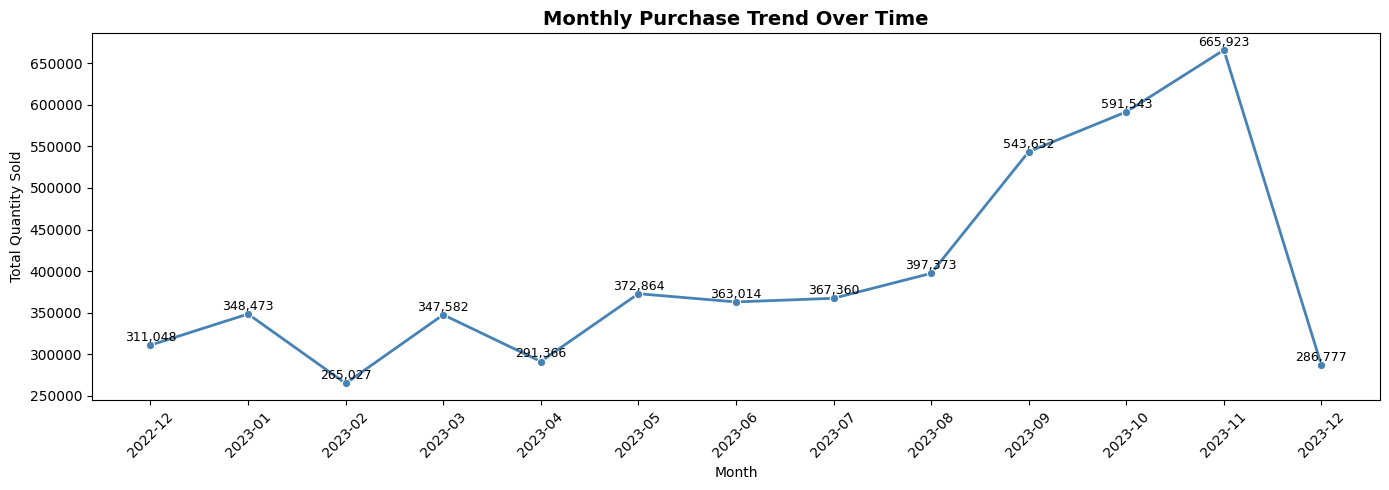

In [9]:
# Chart 3: Monthly Purchase Trend Over Time
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_trend = df.groupby('YearMonth')['Quantity'].sum() .reset_index()
monthly_trend['YearMonth'] = monthly_trend['YearMonth'] .astype(str)

plt.figure(figsize=(14, 5))
ax = sns.lineplot(x='YearMonth', y='Quantity', data=monthly_trend, marker='o', color='steelblue', linewidth=2)
for i, row in monthly_trend.iterrows():
    ax.text(i, row['Quantity'] + 5000, f"{row['Quantity']:,}", ha='center', fontsize=9)
plt.title('Monthly Purchase Trend Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

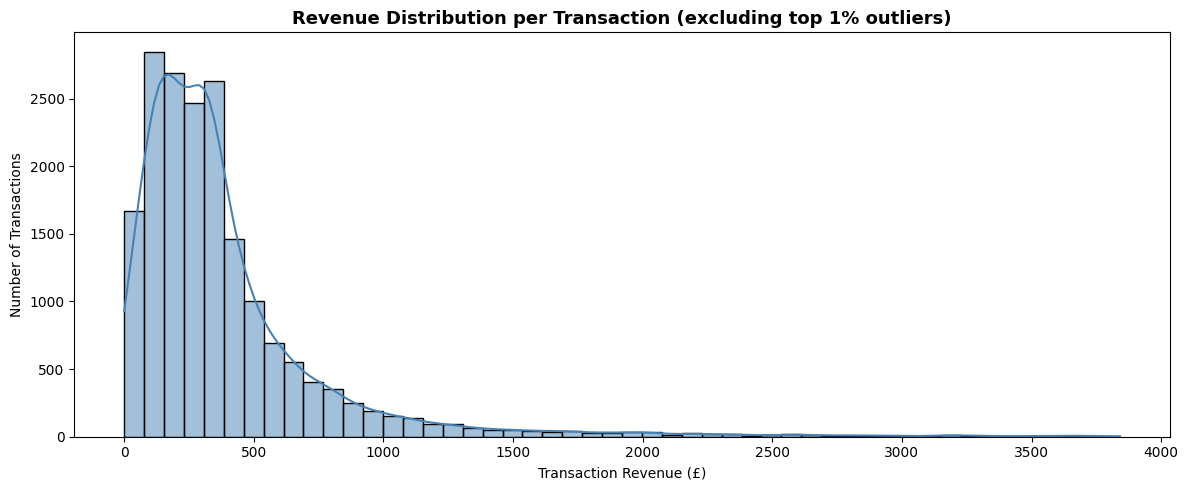

Median transaction value: £302.57
Mean transaction value:   £479.56
Max transaction value:    £168,469.60


In [10]:
# Chart 4: Revenue Distribution per Transaction
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

plt.figure(figsize=(12, 5))
transaction_revenue = df.groupby('InvoiceNo')['TotalPrice'].sum()
transaction_revenue_filtered = transaction_revenue[transaction_revenue < transaction_revenue.quantile(0.99)]

sns.histplot(transaction_revenue_filtered, bins=50, color='steelblue', kde=True)
plt.title('Revenue Distribution per Transaction (excluding top 1% outliers)', fontsize=13, fontweight='bold')
plt.xlabel('Transaction Revenue (£)')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

print(f"Median transaction value: £{transaction_revenue.median():.2f}")
print(f"Mean transaction value:   £{transaction_revenue.mean():.2f}")
print(f"Max transaction value:    £{transaction_revenue.max():,.2f}")

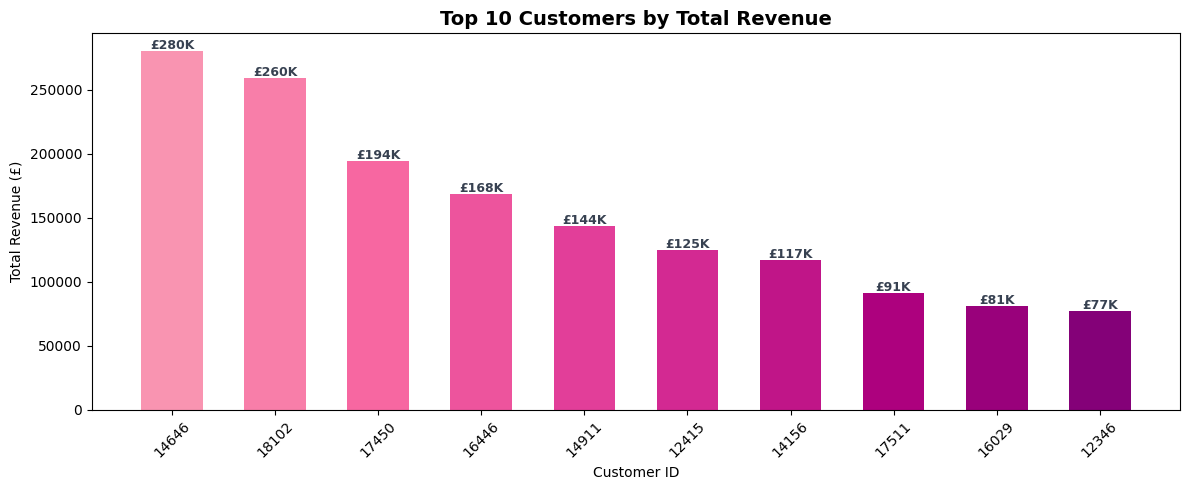

Top customer ID: 14646 — £280,206.02
Top 10 customers contribute: £1,537,659.21 total revenue


In [11]:
# Chart 5: Top 10 Customers by Total Revenue
plt.figure(figsize=(12, 5))
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)
colors = plt.cm.RdPu(np.linspace(0.4, 0.85, len(top_customers)))

ax = plt.gca()
bars = ax.bar([str(c) for c in top_customers.index], top_customers.values, color=colors, width=0.6)

for bar, val in zip(bars, top_customers.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1500,
            f'£{val/1000:.0f}K', ha='center', fontsize=9, fontweight='bold', color='#374151')

plt.title('Top 10 Customers by Total Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Customer ID')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Top customer ID: {top_customers.index[0]} — £{top_customers.values[0]:,.2f}")
print(f"Top 10 customers contribute: £{top_customers.sum():,.2f} total revenue")

In [12]:
# ─── Step 5: RFM Feature Engineering ────────────────────────────────────────

# Reference date = 1 day after the last transaction in the dataset
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
). reset_index()

print("RFM Table Shape:", rfm.shape)
print()
print(rfm.head(10))
print()
print("RFM Stats:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe() .round(2))

RFM Table Shape: (4338, 4)

   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40
5       12352       36          8   2506.04
6       12353      204          1     89.00
7       12354      232          1   1079.40
8       12355      214          1    459.40
9       12356       23          3   2811.43

RFM Stats:
       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.27    2048.69
std     100.01       7.70    8985.23
min       1.00       1.00       3.75
25%      18.00       1.00     306.48
50%      51.00       2.00     668.57
75%     142.00       5.00    1660.60
max     374.00     209.00  280206.02


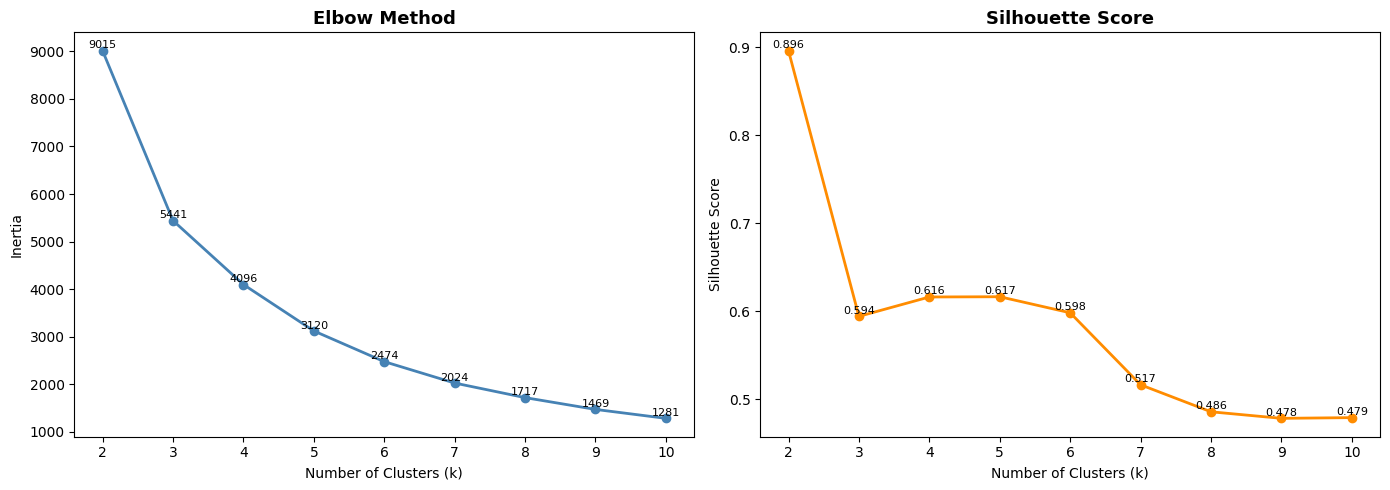

In [13]:
# ─── Step 6: Normalize RFM + Find Optimal Clusters ──────────────────────────

# Normalize RFM values
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Elbow Method + Silhouette Score
inertia = []
silhouette_scores = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, km.labels_))

# Plot both side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Curve
axes[0].plot(K, inertia, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
for i, (k, val) in enumerate(zip(K, inertia)):
    axes[0].text(k, val + 50, f'{val:.0f}', ha='center', fontsize=8)

# Silhouette Score
axes[1].plot(K, silhouette_scores, marker='o', color='darkorange', linewidth=2)
axes[1].set_title('Silhouette Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
for i, (k, val) in enumerate(zip(K, silhouette_scores)):
    axes[1].text(k, val + 0.003, f'{val:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

In [14]:
# ─── Step 7: Run KMeans Clustering (k=4) ────────────────────────────────────

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Check cluster sizes
print("Cluster sizes:\n", rfm['Cluster'].value_counts().sort_index())
print()

# RFM averages per cluster
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print("Cluster RFM Averages:\n", cluster_summary)

Cluster sizes:
 Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64

Cluster RFM Averages:
          Recency  Frequency   Monetary
Cluster                               
0          43.70       3.68    1353.63
1         248.08       1.55     478.85
2           7.38      82.54  127187.96
3          15.50      22.33   12690.50


In [15]:
# ─── Step 7 continued: Label the Clusters ───────────────────────────────────

cluster_labels = {
    2: 'High-Value',
    3: 'Regular',
    0: 'Occasional',
    1: 'At-Risk'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_labels)

print("Segment distribution:\n", rfm['Segment'].value_counts())
print()
print(rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Segment']].head(10))

Segment distribution:
 Segment
Occasional    3054
At-Risk       1067
Regular        204
High-Value      13
Name: count, dtype: int64

   CustomerID  Recency  Frequency  Monetary     Segment
0       12346      326          1  77183.60     Regular
1       12347        2          7   4310.00  Occasional
2       12348       75          4   1797.24  Occasional
3       12349       19          1   1757.55  Occasional
4       12350      310          1    334.40     At-Risk
5       12352       36          8   2506.04  Occasional
6       12353      204          1     89.00     At-Risk
7       12354      232          1   1079.40     At-Risk
8       12355      214          1    459.40     At-Risk
9       12356       23          3   2811.43  Occasional


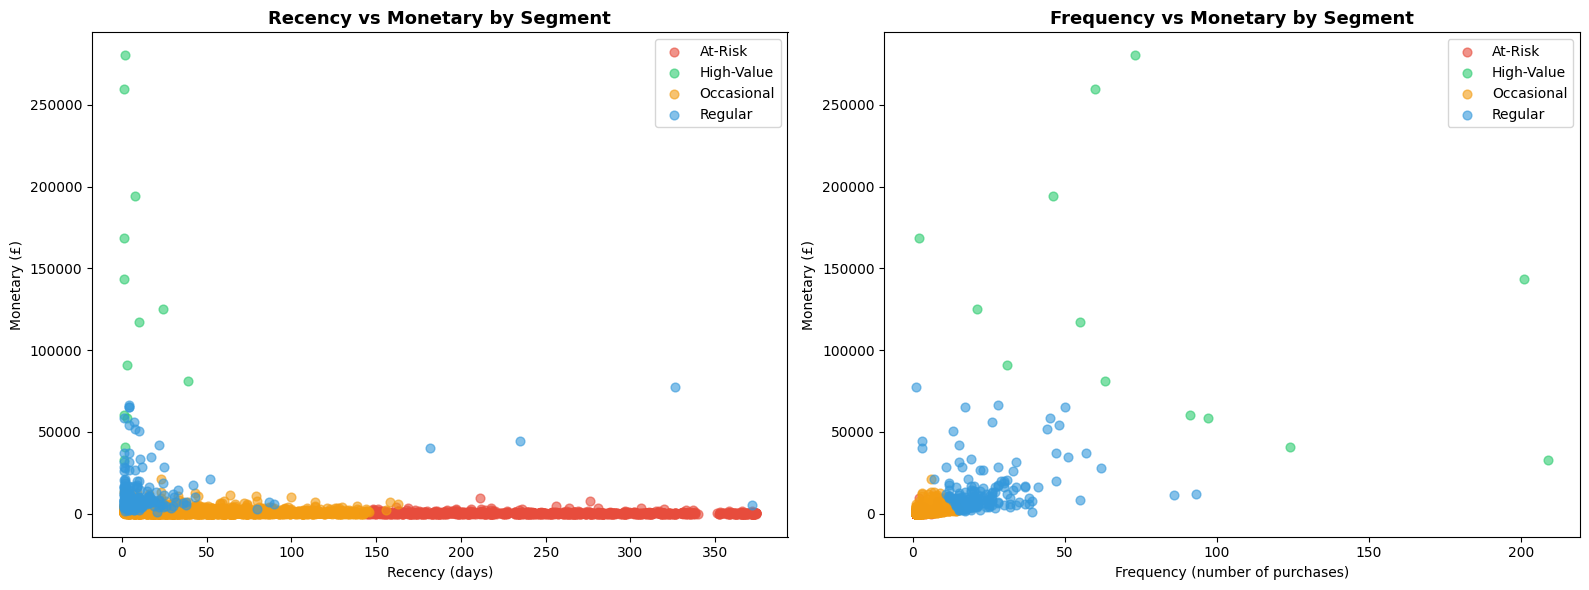

In [16]:
# ─── Step 8: Visualize Clusters ──────────────────────────────────────────────

colors = {'High-Value': '#2ecc71', 'Regular': '#3498db', 
          'Occasional': '#f39c12', 'At-Risk': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Recency vs Monetary
for segment, group in rfm.groupby('Segment'):
    axes[0].scatter(group['Recency'], group['Monetary'], 
                    label=segment, alpha=0.6, s=40, color=colors[segment])
axes[0].set_title('Recency vs Monetary by Segment', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Monetary (£)')
axes[0].legend()

# Plot 2: Frequency vs Monetary
for segment, group in rfm.groupby('Segment'):
    axes[1].scatter(group['Frequency'], group['Monetary'], 
                    label=segment, alpha=0.6, s=40, color=colors[segment])
axes[1].set_title('Frequency vs Monetary by Segment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Frequency (number of purchases)')
axes[1].set_ylabel('Monetary (£)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
# ─── Step 9: Save the Model & Data ──────────────────────────────────────────

import pickle

# Save the KMeans model
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save the RFM table with segments
rfm.to_csv('rfm_segments.csv', index=False)

print("kmeans_model.pkl saved")
print("scaler.pkl saved")
print("rfm_segments.csv saved")

kmeans_model.pkl saved
scaler.pkl saved
rfm_segments.csv saved


In [18]:
# ─── Step 10: Collaborative Filtering — Product Recommendation System ────────

# Build Customer-Product matrix (pivot table)
# Rows = CustomerID, Columns = Product Description, Values = Quantity purchased
customer_product_matrix = df.pivot_table(
    index='CustomerID', 
    columns='Description', 
    values='Quantity', 
    aggfunc='sum'
).fillna(0)

print("Customer-Product Matrix Shape:", customer_product_matrix.shape)
print()

# Compute cosine similarity between products (transpose so products are rows)
product_similarity = cosine_similarity(customer_product_matrix.T)

# Wrap in a DataFrame for easy lookup
product_similarity_df = pd.DataFrame(
    product_similarity, 
    index=customer_product_matrix.columns, 
    columns=customer_product_matrix.columns
)

print("Product Similarity Matrix Shape:", product_similarity_df.shape)
print()
print("Sample — products similar to 'WHITE HANGING HEART T-LIGHT HOLDER':")
sample = product_similarity_df['WHITE HANGING HEART T-LIGHT HOLDER'].sort_values(ascending=False) [1:6]
print(sample)

Customer-Product Matrix Shape: (4338, 3877)

Product Similarity Matrix Shape: (3877, 3877)

Sample — products similar to 'WHITE HANGING HEART T-LIGHT HOLDER':
Description
GIN + TONIC DIET METAL SIGN         0.750192
RED HANGING HEART T-LIGHT HOLDER    0.658714
WASHROOM METAL SIGN                 0.643520
LAUNDRY 15C METAL SIGN              0.642200
GREEN VINTAGE SPOT BEAKER           0.631463
Name: WHITE HANGING HEART T-LIGHT HOLDER, dtype: float64


In [19]:
# Save product similarity matrix and product list for Streamlit
product_similarity_df.to_csv('product_similarity.csv')
product_list = customer_product_matrix.columns.tolist()

with open('product_list.pkl', 'wb') as f:
    pickle.dump(product_list, f)

print(f"product_similarity.csv saved")
print(f"product_list.pkl saved")
print(f"Total products available for recommendation: {len(product_list)}")

product_similarity.csv saved
product_list.pkl saved
Total products available for recommendation: 3877
